# Experiment 10: Denoising and Dimensionality Reduction using Autoencoders

## Step 1
Import the required libraries.

In [1]:
import os
import gc
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
import kagglehub

torch.manual_seed(42)
np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


## Step 2
Load the dataset, flatten the images to 784 values and define a function to add noise.

In [2]:
path = kagglehub.dataset_download("andrewmvd/medical-mnist")
files = []
for ext in ("jpeg", "jpg", "png"):
    files += glob.glob(os.path.join(path, "**", f"*.{ext}"), recursive=True)
files = sorted(files)
class_names = sorted({os.path.basename(os.path.dirname(f)) for f in files})


def load_image(f):
    return np.array(Image.open(f).convert("L").resize((64, 64)), dtype=np.uint8)


images = np.stack([load_image(f) for f in files])
labels = np.array([class_names.index(os.path.basename(os.path.dirname(f))) for f in files])
order = np.random.permutation(len(images))
X = torch.tensor(images[order]).unsqueeze(1)
y = torch.tensor(labels[order]).long()
del images

n_test = int(0.15 * len(X))
Xtr, ytr = X[:-n_test], y[:-n_test]
Xte, yte = X[-n_test:], y[-n_test:]

noise_std = 0.2
latent_dim = 64
batch_size = 128


def to_float(xb):
    return xb.to(device).float() / 255.0


def add_noise(x):
    return (x + noise_std * torch.randn_like(x)).clamp(0, 1)


print(class_names)
print(Xtr.shape, Xte.shape)

100%|██████████| 84.8M/84.8M [01:19<00:00, 1.12MB/s]

Extracting files...


['AbdomenCT', 'BreastMRI', 'CXR', 'ChestCT', 'Hand', 'HeadCT']
torch.Size([50111, 1, 64, 64]) torch.Size([8843, 1, 64, 64])


## Step 3
Define the encoder (784, 256, 128, 32) and the decoder (32, 128, 256, 784) layers.

In [3]:
class ConvAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, latent_dim),
        )
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 64 * 8 * 8), nn.ReLU(),
            nn.Unflatten(1, (64, 8, 8)),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 4, stride=2, padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.dec(self.enc(x))


epochs = 10
use_amp = device.type == "cuda"
model = ConvAE().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
scaler = torch.amp.GradScaler("cuda", enabled=use_amp)
print(f"parameters: {sum(p.numel() for p in model.parameters())}")

parameters: 593009


## Step 4
Train the autoencoder for 12 epochs with noisy images as input and clean images as target.

In [4]:
def free_memory():
    if device.type == "cuda":
        torch.cuda.empty_cache()

def is_oom(e):
    return isinstance(e, torch.cuda.OutOfMemoryError) or "out of memory" in str(e).lower()

def safe_call(fn, bs, min_bs=8):
    while True:
        try:
            return fn(bs), bs
        except RuntimeError as e:
            if not is_oom(e):
                raise
        model.zero_grad(set_to_none=True)
        gc.collect()
        free_memory()
        if bs <= min_bs:
            raise RuntimeError("out of memory even at the smallest batch size")
        bs = max(min_bs, bs // 2)
        print(f"out of memory, retrying with batch size {bs}")


def train_one_epoch(bs):
    model.train()
    tot = 0.0
    n = 0
    for i in torch.randperm(len(Xtr)).split(bs):
        x = to_float(Xtr[i])
        opt.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type, enabled=use_amp):
            out = model(add_noise(x))
        loss = F.mse_loss(out.float(), x)
        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()
        tot += loss.item() * len(x)
        n += len(x)
    return tot / n


for ep in range(epochs):
    train_loss, batch_size = safe_call(train_one_epoch, batch_size)
    free_memory()
    print(f"epoch {ep + 1}/{epochs} batch_size {batch_size} train_mse {train_loss:.5f}")

epoch 1/10 batch_size 128 train_mse 0.02377
epoch 2/10 batch_size 128 train_mse 0.00994
epoch 3/10 batch_size 128 train_mse 0.00809
epoch 4/10 batch_size 128 train_mse 0.00713
epoch 5/10 batch_size 128 train_mse 0.00654
epoch 6/10 batch_size 128 train_mse 0.00615
epoch 7/10 batch_size 128 train_mse 0.00586
epoch 8/10 batch_size 128 train_mse 0.00566
epoch 9/10 batch_size 128 train_mse 0.00547
epoch 10/10 batch_size 128 train_mse 0.00533


## Step 5
Test it on the test data, output the denoising error, compare the 32 encoded features with PCA using a classifier and save the picture.

noisy vs clean mse: 0.03054
denoised vs clean mse: 0.00552
compression: 4096 -> 64 (64x)
autoencoder reconstruction mse (clean test): 0.00614
PCA (64 comps) reconstruction mse (clean test): 0.00781
linear classifier on raw pixels (4096): 0.9864
linear classifier on autoencoder latent (64): 0.9959
linear classifier on PCA (64): 0.9818


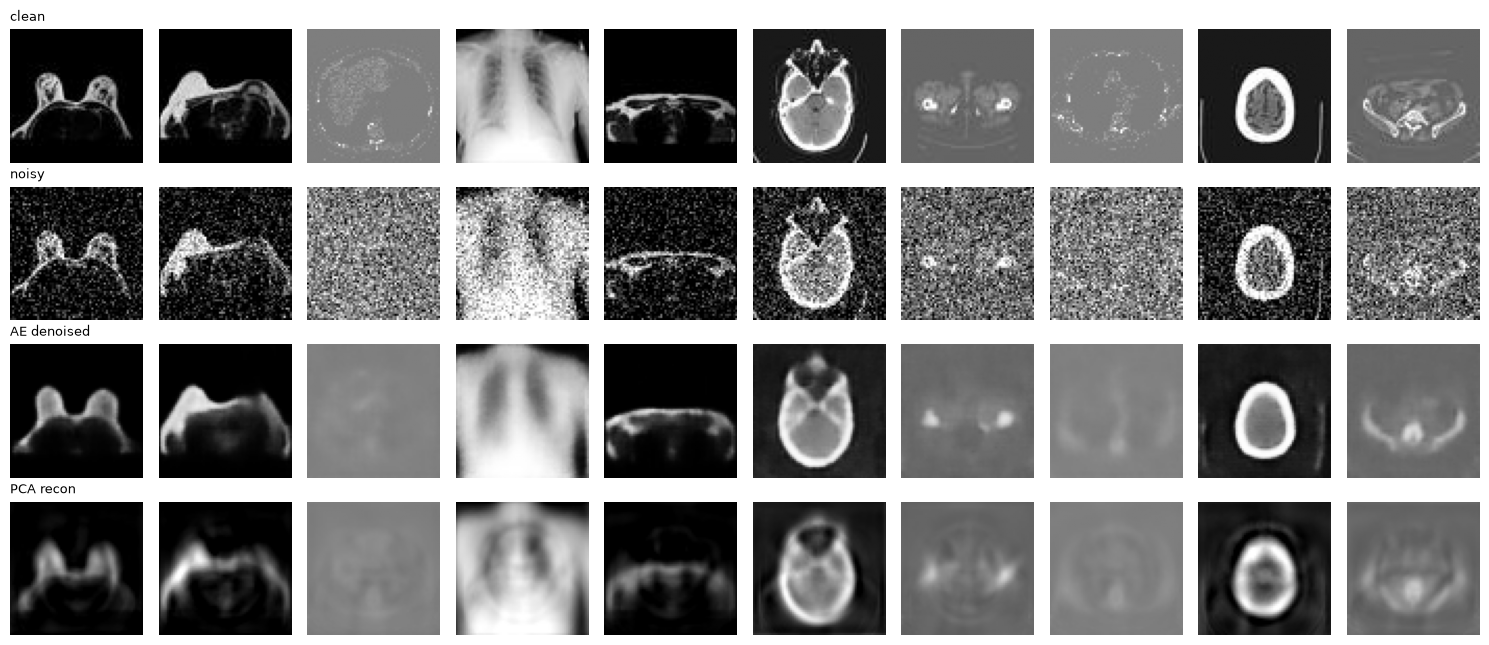

In [5]:
def test_pass(bs):
    model.eval()
    torch.manual_seed(0)
    sq_noisy = 0.0
    sq_den = 0.0
    n = 0
    with torch.no_grad():
        for i in range(0, len(Xte), bs):
            x = to_float(Xte[i:i + bs])
            nx = add_noise(x)
            with torch.autocast(device_type=device.type, enabled=use_amp):
                out = model(nx)
            sq_noisy += ((nx - x) ** 2).sum().item()
            sq_den += ((out.float() - x) ** 2).sum().item()
            n += x.numel()
    return sq_noisy, sq_den, n
def encode(X, bs):
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(X), bs):
            with torch.autocast(device_type=device.type, enabled=use_amp):
                out.append(model.enc(to_float(X[i:i + bs])).float().cpu())
    return torch.cat(out)

def linear_probe(Ftr_, ytr_, Fte_, yte_, epochs=20):
    mu = Ftr_.mean(0, keepdim=True)
    sd = Ftr_.std(0, keepdim=True).clamp(min=1e-2)
    Ftr_ = (Ftr_ - mu) / sd
    Fte_ = (Fte_ - mu) / sd
    clf = nn.Linear(Ftr_.shape[1], len(class_names)).to(device)
    o = torch.optim.Adam(clf.parameters(), lr=1e-2)
    for _ in range(epochs):
        for i in torch.randperm(len(Ftr_)).split(512):
            o.zero_grad()
            F.cross_entropy(clf(Ftr_[i].to(device)), ytr_[i].to(device)).backward()
            o.step()
    with torch.no_grad():
        pred = torch.cat([clf(Fte_[i:i + 2048].to(device)).argmax(1).cpu() for i in range(0, len(Fte_), 2048)])
    return (pred == yte_).float().mean().item()


free_memory()
(sq_noisy, sq_den, n), _ = safe_call(test_pass, 256)
print(f"noisy vs clean mse: {sq_noisy / n:.5f}")
print(f"denoised vs clean mse: {sq_den / n:.5f}")
print(f"compression: 4096 -> {latent_dim} ({4096 / latent_dim:.0f}x)")

n_probe = min(15000, len(Xtr))
Xsub = Xtr[:n_probe]
ysub = ytr[:n_probe]
Zsub, _ = safe_call(lambda bs: encode(Xsub, bs), 256)
Zte, _ = safe_call(lambda bs: encode(Xte, bs), 256)

raw_sub = Xsub.flatten(1).float() / 255.0
raw_te = Xte.flatten(1).float() / 255.0
mean = raw_sub.mean(0, keepdim=True)
U, S, V = torch.pca_lowrank(raw_sub - mean, q=latent_dim, center=False, niter=4)
Psub = (raw_sub - mean) @ V
Pte = (raw_te - mean) @ V
pca_rec = Pte @ V.T + mean

with torch.no_grad():
    ae_rec = torch.cat([model(to_float(Xte[i:i + 256])).float().cpu() for i in range(0, len(Xte), 256)]).flatten(1)
print(f"autoencoder reconstruction mse (clean test): {F.mse_loss(ae_rec, raw_te).item():.5f}")
print(f"PCA ({latent_dim} comps) reconstruction mse (clean test): {F.mse_loss(pca_rec, raw_te).item():.5f}")

print(f"linear classifier on raw pixels (4096): {linear_probe(raw_sub, ysub, raw_te, yte):.4f}")
print(f"linear classifier on autoencoder latent ({latent_dim}): {linear_probe(Zsub, ysub, Zte, yte):.4f}")
print(f"linear classifier on PCA ({latent_dim}): {linear_probe(Psub, ysub, Pte, yte):.4f}")

torch.manual_seed(0)
with torch.no_grad():
    cx = to_float(Xte[:10])
    nx = add_noise(cx)
    den = model(nx).float().cpu()
rows = [cx.cpu(), nx.cpu(), den, pca_rec[:10].view(-1, 1, 64, 64)]
names = ["clean", "noisy", "AE denoised", "PCA recon"]
fig, axes = plt.subplots(4, 10, figsize=(15, 6.5))
for r in range(4):
    for i in range(10):
        axes[r, i].imshow(rows[r][i, 0], cmap="gray", vmin=0, vmax=1)
        axes[r, i].axis("off")
    axes[r, 0].set_title(names[r], loc="left", fontsize=9)
plt.tight_layout()
plt.savefig("exp10_medical_autoencoder.png", dpi=100)
plt.show()